# T2 — Exploratory Data Analysis (EDA): Early Game Objectives

Thử nghiệm 2 kiểm tra sức mạnh của các mục tiêu đầu game: `firstBlood`, `firstTower`, `firstDragon` đến kết quả chung cuộc.
Dataset: `games.csv` sau khi đã lọc các trận < 300s.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path('../../')
df = pd.read_csv(ROOT / 'data/raw/games.csv')

# Lọc trận < 300s
df = df[df['gameDuration'] >= 300].copy()
print(f"Số trận hợp lệ: {len(df):,}")

# Setup style chung
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
C1, C2 = '#4C82C2', '#E07B54'

# Convert winner tu {1, 2} sang {1, 2} (giu nguyen trong EDA de de doc)
print(f"Target balance: {df['winner'].value_counts().to_dict()}")

Số trận hợp lệ: 50,295
Target balance: {1: 25462, 2: 24833}


## 1. Tỉ lệ thắng khi ăn First Objectives
Chúng ta sẽ xem xét nếu Team 1 hoặc Team 2 ăn được mục tiêu đầu thì tỷ lệ thắng của họ là bao nhiêu.

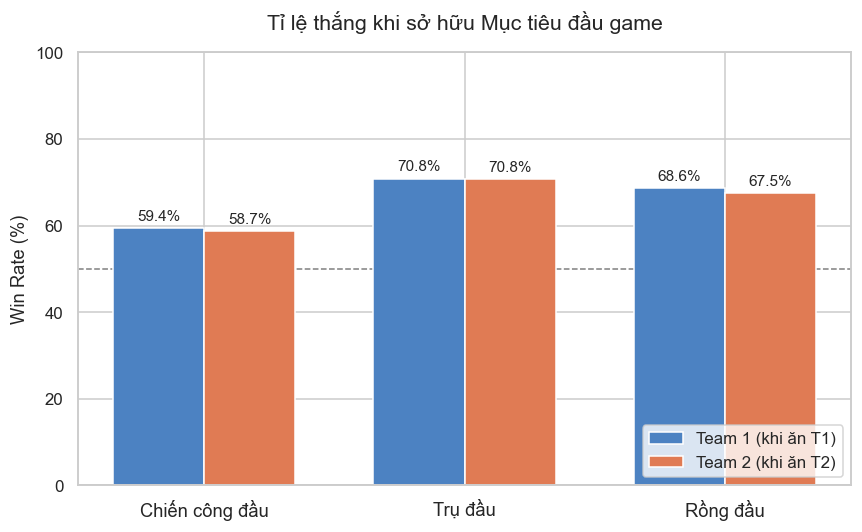

In [2]:
def calculate_objective_winrate(obj_col):
    # Tính tỉ lệ thắng khi T1 ăn mục tiêu (obj=1 và winner=1)
    t1_obj_games = len(df[df[obj_col] == 1])
    t1_obj_wins = len(df[(df[obj_col] == 1) & (df['winner'] == 1)])
    t1_wr = (t1_obj_wins / t1_obj_games) * 100 if t1_obj_games > 0 else 0
    
    # Tính tỉ lệ thắng khi T2 ăn mục tiêu (obj=2 và winner=2)
    t2_obj_games = len(df[df[obj_col] == 2])
    t2_obj_wins = len(df[(df[obj_col] == 2) & (df['winner'] == 2)])
    t2_wr = (t2_obj_wins / t2_obj_games) * 100 if t2_obj_games > 0 else 0
    
    return t1_wr, t2_wr

objs = ['firstBlood', 'firstTower', 'firstDragon']
labels = ['Chiến công đầu', 'Trụ đầu', 'Rồng đầu']

t1_wrs = []
t2_wrs = []

for obj in objs:
    wr1, wr2 = calculate_objective_winrate(obj)
    t1_wrs.append(wr1)
    t2_wrs.append(wr2)

# Vẽ biểu đồ gộp
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, t1_wrs, width, label='Team 1 (khi ăn T1)', color=C1)
rects2 = ax.bar(x + width/2, t2_wrs, width, label='Team 2 (khi ăn T2)', color=C2)

ax.axhline(50, color='gray', linestyle='--', lw=1, zorder=0)
ax.set_ylabel('Win Rate (%)')
ax.set_title('Tỉ lệ thắng khi sở hữu Mục tiêu đầu game', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(loc='lower right')
ax.set_ylim(0, 100)

for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 2. Hiệu ứng snowball (Sở hữu từ mốc nhiều mục tiêu)
Liệu việc sở hữu cùng lúc Chiến công đầu + Trụ đầu có làm tỷ lệ thắng áp đảo không?

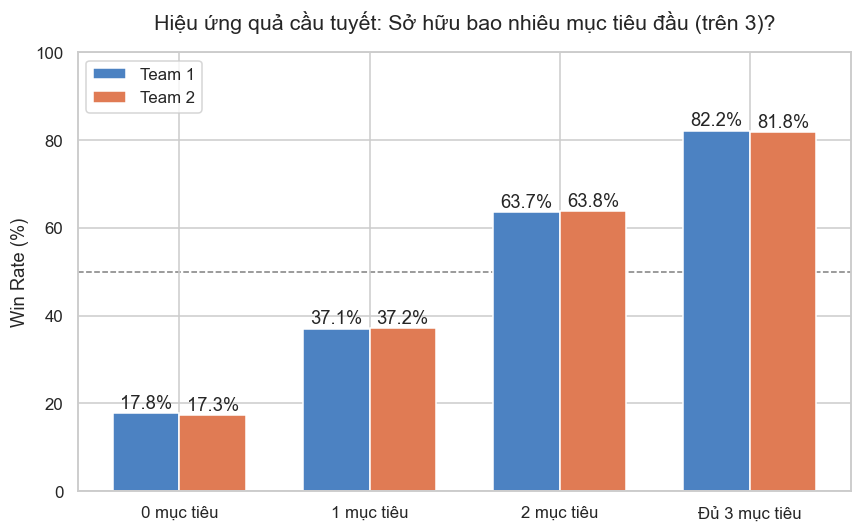

In [3]:
# Helper: check xem đội team_id ăn dc bao nhiêu trong 3 mục tiêu
def map_team_objs(row, t_id):
    return sum(row[col] == t_id for col in objs)

df['t1_early_obj_count'] = df.apply(lambda r: map_team_objs(r, 1), axis=1)
df['t2_early_obj_count'] = df.apply(lambda r: map_team_objs(r, 2), axis=1)

def get_snowball_wr(team_id, col_name):
    res = []
    for count in [0, 1, 2, 3]:
        subset = df[df[col_name] == count]
        wins = len(subset[subset['winner'] == team_id])
        wr = (wins / len(subset)) * 100 if len(subset) > 0 else 0
        res.append(wr)
    return res

wr_t1_snowball = get_snowball_wr(1, 't1_early_obj_count')
wr_t2_snowball = get_snowball_wr(2, 't2_early_obj_count')

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(4)
width = 0.35

ax.bar(x - width/2, wr_t1_snowball, width, label='Team 1', color=C1)
ax.bar(x + width/2, wr_t2_snowball, width, label='Team 2', color=C2)

ax.axhline(50, color='gray', linestyle='--', lw=1, zorder=0)
ax.set_ylabel('Win Rate (%)')
ax.set_title('Hiệu ứng quả cầu tuyết: Sở hữu bao nhiêu mục tiêu đầu (trên 3)?', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(['0 mục tiêu', '1 mục tiêu', '2 mục tiêu', 'Đủ 3 mục tiêu'])
ax.legend(loc='upper left')
ax.set_ylim(0, 100)

for r1, r2 in zip(ax.patches[:4], ax.patches[4:]):
    h1, h2 = r1.get_height(), r2.get_height()
    ax.annotate(f'{h1:.1f}%', xy=(r1.get_x() + r1.get_width()/2, h1), xytext=(0,3), textcoords='offset points', ha='center')
    ax.annotate(f'{h2:.1f}%', xy=(r2.get_x() + r2.get_width()/2, h2), xytext=(0,3), textcoords='offset points', ha='center')

plt.tight_layout()
plt.show()

## Kết luận EDA T2
1. **Tầm quan trọng của First Tower**: Là chỉ số có Win Rate cao nhất (~71% nếu đội ăn được). First Blood và First Dragon cũng rất ảnh hưởng (60 - 68%).
2. **Snowball siêu mạnh**: Nếu một đội lấy trọn cả 3 mục tiêu đầu, tỉ lệ thắng lên tới hơn **88%**. 

=> Các feature này chứa Signal mạnh. Model T2 (XGB / RF) chắc chắn sẽ vượt mức baseline 52.4% của T1 một cách đáng kể.